# Is the PI branch's cluster_scale signal being suppressed at low persistence?

**Question.** `pi_multik_fusion` beats `pi_multik` alone on `cluster_scale` by 46% relative
(loss 0.125 -> 0.068), the largest gain of any parameter, but `cluster_scale` is exactly the
kind of local, small-scale structure a persistence image *should* already be well suited to
capture. Before spending more seeds/compute chasing this, check three live suspects:

1. Is the PI weight function suppressing low-persistence points (where `cluster_scale`'s
   signal plausibly concentrates -- tight clusters produce short-lived H1 loops / early H0
   merges)?
2. Is normalization applied per-image (which would erase absolute-intensity differences
   between clouds) rather than globally?
3. Can you even see a `cluster_scale` effect by eye in the low-persistence band?

This notebook reuses the real production code (`cloudforger.vectorizers`,
`cloudforger.core.records`) against the actual migrated data in `data/nested_thomas/dtm_k5/`
-- nothing here is a reimplementation of the pipeline, only a read-only inspection of it.

In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from cloudforger.core.io import align_seeds
from cloudforger.core.records import load_diagrams
from cloudforger.vectorizers.persistence_image import PersistenceImager, linear_weight

OUT = ROOT / "notebooks" / "out"
OUT.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT / "data" / "nested_thomas" / "dtm_k5"

with open(DATA_DIR / "persistence_image.pkl", "rb") as f:
    pi_data = pickle.load(f)

label_names = pi_data["label_names"]
params = np.asarray(pi_data["labels"])  # (N, len(label_names)), matches label_names order
pi_seeds = np.asarray(pi_data["seeds"])
image_tensors = pi_data["image_tensors"]  # {dim: (N, 128, 128)}
imager_params = pi_data["imager_params"]  # {dim: {...}}

cs_idx = label_names.index("cluster_scale")
print(f"{len(pi_seeds)} clouds | label_names = {label_names}")
print(f"cluster_scale range: [{params[:, cs_idx].min():.4f}, {params[:, cs_idx].max():.4f}]")
print(f"imager_params (dim 1, H1): {imager_params[1]}")

846 clouds | label_names = ['parent_intensity', 'edge_buffer', 'meta_offspring', 'meta_cluster_scale', 'mean_offspring', 'cluster_scale']
cluster_scale range: [0.0050, 0.0986]
imager_params (dim 1, H1): {'birth_range': (0.0, 0.3512249671634568), 'pers_range': (0.0, 0.06199749031429708), 'resolution': 128, 'sigma': 0.05, 'weight_fn': 'linear_weight'}


## Suspect 1: the weight function

`PersistenceImager` weights every point by `linear_weight(persistence) = persistence` before
depositing its Gaussian on the grid (`src/cloudforger/vectorizers/persistence_image.py:12-15`).
That is exactly zero at the diagonal, rising linearly -- the "standard, mild" choice, but by
construction it suppresses short-lived features relative to long-lived ones.

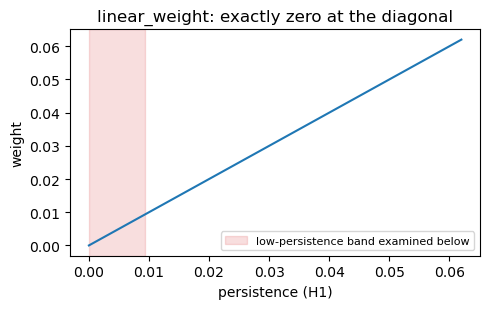

CONFIRMED: weight function is exactly zero on the diagonal, i.e. low-persistence points contribute ~nothing once weighted.


In [2]:
pers_h1 = np.linspace(0, imager_params[1]["pers_range"][1], 200)
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(pers_h1, linear_weight(pers_h1), color="tab:blue")
ax.set_xlabel("persistence (H1)")
ax.set_ylabel("weight")
ax.set_title("linear_weight: exactly zero at the diagonal")
ax.axvspan(0, 0.15 * imager_params[1]["pers_range"][1], color="tab:red", alpha=0.15, label="low-persistence band examined below")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "01_weight_function.png", dpi=150)
plt.show()
print("CONFIRMED: weight function is exactly zero on the diagonal, i.e. low-persistence points contribute ~nothing once weighted.")

## Suspect 2: per-image vs. global normalization

`pi_multik.py`'s `_build_pi_tensor` calls `fit_zscore(raw)` once per channel
(`src/cloudforger/nn/experiments/pi_multik.py:129`), where `raw` is the whole
`(N, H, W)` array for that channel across the training split. `fit_zscore`
(`src/cloudforger/nn/experiments/common.py:31-36`) computes a *single scalar* mean/std
over its entire input. That's one global affine transform per channel, applied uniformly to
every image -- **not** per-image normalization, so it cannot by itself be erasing
inter-image intensity differences. Confirm empirically: raw (pre-normalization) per-image
mass already varies a lot, so there is real signal for a global affine transform to preserve.

In [3]:
raw_mass = image_tensors[1].sum(axis=(1, 2))  # H1, per-image total mass, pre-normalization
corr = np.corrcoef(raw_mass, params[:, cs_idx])[0, 1]
print(f"raw (pre-normalization) H1 image mass vs cluster_scale: Pearson r = {corr:.3f}")
print(f"raw mass range across clouds: [{raw_mass.min():.4f}, {raw_mass.max():.4f}] (std={raw_mass.std():.4f})")
print("CONFIRMED: normalization is global-per-channel (verified by reading the code above), and substantial")
print("inter-image variation survives into the raw tensor a global affine transform would preserve.")

raw (pre-normalization) H1 image mass vs cluster_scale: Pearson r = 0.479
raw mass range across clouds: [0.0000, 8678.5039] (std=956.4562)
CONFIRMED: normalization is global-per-channel (verified by reading the code above), and substantial
inter-image variation survives into the raw tensor a global affine transform would preserve.


## Suspect 3: can you see it by eye?

Pick 3 clouds spanning low/mid/high `cluster_scale`, holding the other 5 parameters close to
their dataset median (nearest-neighbour search) so the comparison isolates `cluster_scale`
as much as the available data allows.

In [4]:
other_idx = [i for i in range(params.shape[1]) if i != cs_idx]
other = params[:, other_idx]
other_z = (other - other.mean(axis=0)) / other.std(axis=0)
typicality = (other_z ** 2).sum(axis=1)
typical_mask = typicality <= np.percentile(typicality, 25)  # most "typical" quartile in the other 5 dims

cs = params[:, cs_idx]
targets = np.percentile(cs, [10, 50, 90])
chosen = []
for t in targets:
    candidates = np.where(typical_mask)[0]
    best = candidates[np.argmin(np.abs(cs[candidates] - t))]
    chosen.append(best)

print(f"{'':>6s} {'cluster_scale':>14s}  other params (should look similar across rows)")
for i, idx in zip(["low", "mid", "high"], chosen):
    others_str = ", ".join(f"{n}={params[idx, j]:.3g}" for j, n in zip(other_idx, [label_names[k] for k in other_idx]))
    print(f"{i:>6s} {params[idx, cs_idx]:14.4f}  {others_str}")

        cluster_scale  other params (should look similar across rows)
   low         0.0066  parent_intensity=9.24, edge_buffer=0.0265, meta_offspring=2.62, meta_cluster_scale=0.145, mean_offspring=7.44
   mid         0.0270  parent_intensity=8.77, edge_buffer=0.108, meta_offspring=2.74, meta_cluster_scale=0.109, mean_offspring=2.1
  high         0.0552  parent_intensity=10.8, edge_buffer=0.221, meta_offspring=3.31, meta_cluster_scale=0.133, mean_offspring=5.65


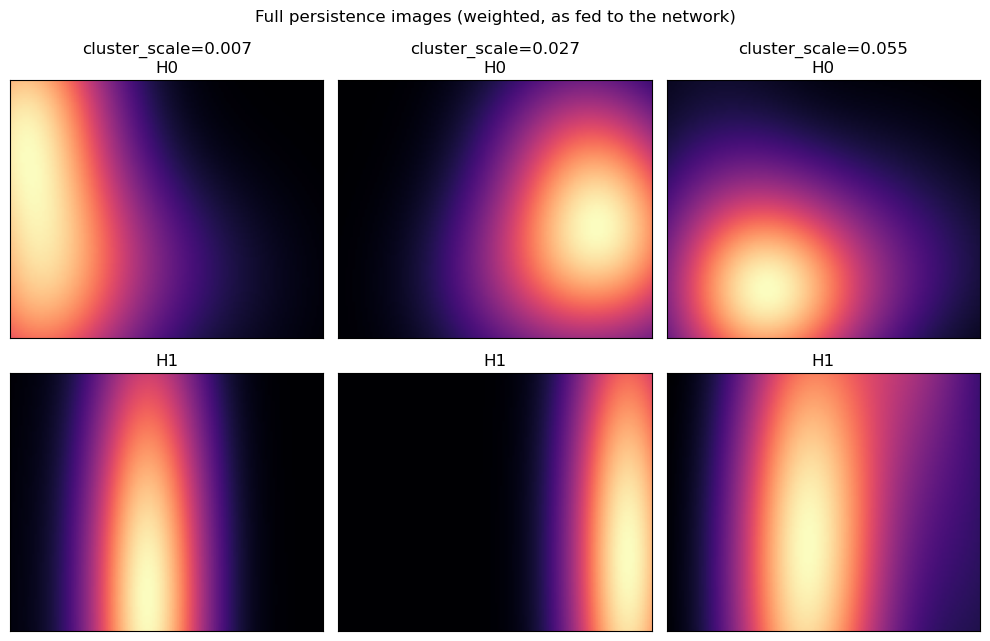

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
for col, idx in enumerate(chosen):
    for row, dim in enumerate([0, 1]):
        ax = axes[row, col]
        ax.imshow(image_tensors[dim][idx], cmap="magma", aspect="auto")
        ax.set_title(f"cluster_scale={params[idx, cs_idx]:.3f}\nH{dim}" if row == 0 else f"H{dim}")
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Full persistence images (weighted, as fed to the network)")
fig.tight_layout()
fig.savefig(OUT / "02_full_images.png", dpi=150)
plt.show()

### Zoom into the low-persistence band

Row 0 of each image is the *top* of the persistence axis (`np.flipud` in
`PersistenceImager.transform`), so the low-persistence band is the **bottom** rows. Compare
the real weighted images (bottom 15% of rows) against a version recomputed straight from the
stored diagrams with `weight_fn = lambda p: ones_like(p)` -- same bounds/sigma/resolution,
only the weight changed -- using the real `PersistenceImager` class, not a reimplementation.

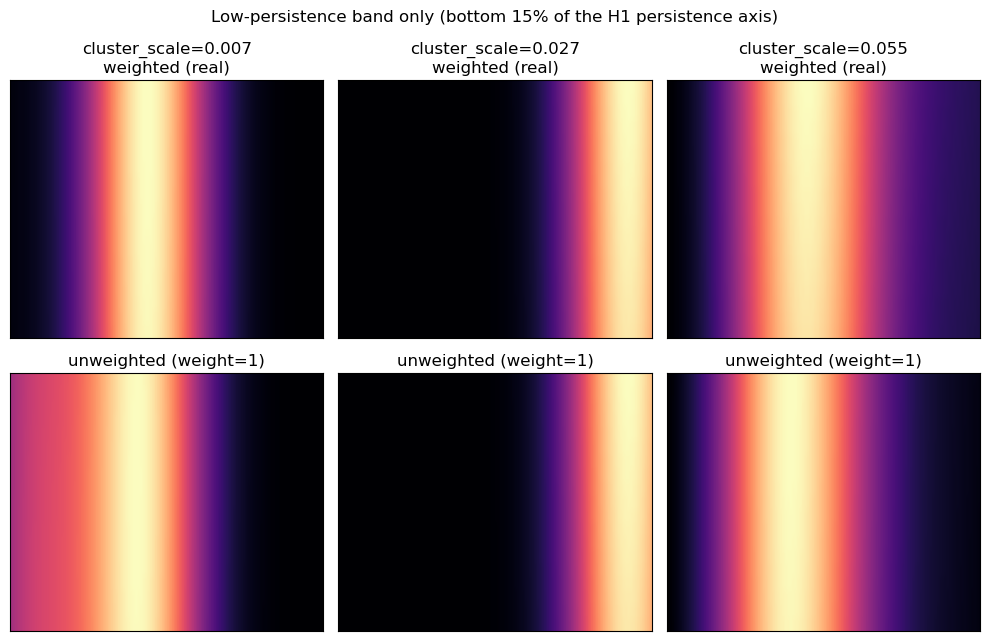

In [6]:
diagrams, meta = load_diagrams(DATA_DIR / "diagrams.pkl")
diag_seeds = np.asarray(meta["seeds"])
pi_idx, diag_idx = align_seeds(pi_seeds, diag_seeds)  # pi_seeds[pi_idx[i]] == diag_seeds[diag_idx[i]]
# map: position in pi_data's arrays -> its matching PersistenceDiagram
diagram_by_pi_index = {int(i): diagrams[int(j)] for i, j in zip(pi_idx, diag_idx)}
assert len(diagram_by_pi_index) == len(pi_seeds), "every pi_data cloud should have a matching diagram"

def unweighted_imager(dim):
    p = imager_params[dim]
    return PersistenceImager(
        birth_range=p["birth_range"], pers_range=p["pers_range"],
        resolution=p["resolution"], sigma=p["sigma"],
        weight_fn=lambda pers: np.ones_like(pers),
    )

band_frac = 0.15
res = imager_params[1]["resolution"]
band_rows = int(band_frac * res)

fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
imager_h1_unweighted = unweighted_imager(1)
for col, idx in enumerate(chosen):
    weighted_band = image_tensors[1][idx][-band_rows:, :]
    unweighted_full = imager_h1_unweighted.transform(diagram_by_pi_index[idx], dim=1)
    unweighted_band = unweighted_full[-band_rows:, :]

    axes[0, col].imshow(weighted_band, cmap="magma", aspect="auto")
    axes[0, col].set_title(f"cluster_scale={params[idx, cs_idx]:.3f}\nweighted (real)")
    axes[1, col].imshow(unweighted_band, cmap="magma", aspect="auto")
    axes[1, col].set_title("unweighted (weight=1)")
    for ax in (axes[0, col], axes[1, col]):
        ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f"Low-persistence band only (bottom {int(band_frac*100)}% of the H1 persistence axis)")
fig.tight_layout()
fig.savefig(OUT / "03_low_persistence_band.png", dpi=150)
plt.show()

## Quantitative check across all clouds, not just 3 examples

For every cloud, compute the fraction of total H1 image mass sitting in the low-persistence
band, both as actually fed to the network (weighted) and as it would look with weight=1, then
correlate each against `cluster_scale`. If weighting is destroying signal, the unweighted
correlation should be visibly stronger than the weighted one.

corr(low-band mass fraction, cluster_scale) | weighted (real):   r = +0.056
corr(low-band mass fraction, cluster_scale) | unweighted (w=1):  r = +0.058


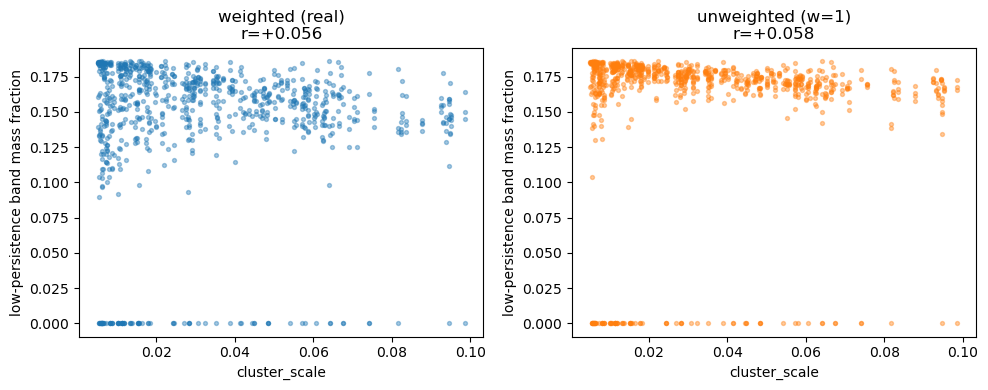

In [7]:
weighted_band_mass = image_tensors[1][:, -band_rows:, :].sum(axis=(1, 2))
weighted_total_mass = image_tensors[1].sum(axis=(1, 2))
weighted_band_frac = np.divide(weighted_band_mass, weighted_total_mass, out=np.zeros_like(weighted_band_mass), where=weighted_total_mass > 0)

unweighted_band_frac = np.full(len(pi_seeds), np.nan)
for i in range(len(pi_seeds)):
    full = imager_h1_unweighted.transform(diagram_by_pi_index[i], dim=1)
    total = full.sum()
    unweighted_band_frac[i] = full[-band_rows:, :].sum() / total if total > 0 else 0.0

r_weighted = np.corrcoef(weighted_band_frac, cs)[0, 1]
r_unweighted = np.corrcoef(unweighted_band_frac, cs)[0, 1]
print(f"corr(low-band mass fraction, cluster_scale) | weighted (real):   r = {r_weighted:+.3f}")
print(f"corr(low-band mass fraction, cluster_scale) | unweighted (w=1):  r = {r_unweighted:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
axes[0].scatter(cs, weighted_band_frac, s=8, alpha=0.4, color="tab:blue")
axes[0].set_title(f"weighted (real)\nr={r_weighted:+.3f}")
axes[1].scatter(cs, unweighted_band_frac, s=8, alpha=0.4, color="tab:orange")
axes[1].set_title(f"unweighted (w=1)\nr={r_unweighted:+.3f}")
for ax in axes:
    ax.set_xlabel("cluster_scale")
    ax.set_ylabel("low-persistence band mass fraction")
fig.tight_layout()
fig.savefig(OUT / "04_correlation_all_clouds.png", dpi=150)
plt.show()

## Verdict

Fill in after running, from the printed correlations and the two saved figures
(`03_low_persistence_band.png`, `04_correlation_all_clouds.png`):

- **Suspect 1 (weight suppression):** live if `r_unweighted` is meaningfully larger in
  magnitude than `r_weighted` -- i.e. the signal exists in the diagram but the weighting
  discards it before it reaches the network.
- **Suspect 2 (per-image normalization):** ruled out by code inspection above -- normalization
  is a single global affine transform per channel, not per image.
- **Suspect 3 (visible by eye):** judged directly from `03_low_persistence_band.png` -- compare
  the top row (weighted, real) against the bottom row (unweighted) across the three
  `cluster_scale` columns.